# <b>Raw Features</b>

## <b>Logistic Regression</b>

CS 422 Overwatch Simple Model

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score, f1_score

Display stuff for easy edits

In [2]:
pd.set_option('display.max_columns', None)
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

Set up teams

In [3]:
df = pd.read_csv("Reduced_Stats.csv")

In [4]:
print(f"Original dataset shape: {df.shape}")
print(f"Expected number of games: {df.shape[0] // 10}")

Original dataset shape: (6110, 14)
Expected number of games: 611


In [5]:
features = [
    "Eliminations", "Damage Dealt", "Assists", "Objective Time",
    "Damage Mitigated", "Healing Done", "Deaths",
    "Solo Kills", "Final Blows"
]

In [6]:
team_stats = df.groupby(
    ["match_id", "round_num", "team"]
)[features].sum().reset_index()

team_results = df.groupby(
    ["match_id", "round_num", "team"]
)["Result"].first().reset_index()

In [7]:
team_data_frame = team_stats.merge(
    team_results,
    on=["match_id", "round_num", "team"]
)

In [8]:
grouped = team_data_frame.groupby(["match_id", "round_num"])

In [9]:
X_rows = []
y_rows = []

for (match, round_), group in grouped:

    if len(group) != 2:
        continue

    t1 = group.iloc[0]
    t2 = group.iloc[1]

    diff = t1[features] - t2[features]

    X_rows.append(diff.values)
    y_rows.append(int(t1["Result"]))

In [10]:
X = pd.DataFrame(X_rows, columns=features)
y = pd.Series(y_rows)

Train/Split here

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

scale

In [12]:
scaler = StandardScaler()

In [13]:
X_train = scaler.fit_transform(X_train)

In [14]:
X_test = scaler.transform(X_test)

Train

In [15]:
model = LogisticRegression(max_iter=5000)

In [16]:
model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

Predict

In [17]:
y_pred = model.predict(X_test)

Evaluation

MODEL PERFORMANCE (Logistic Regression)
Accuracy: 89.34%
F1 Score : 88.29%


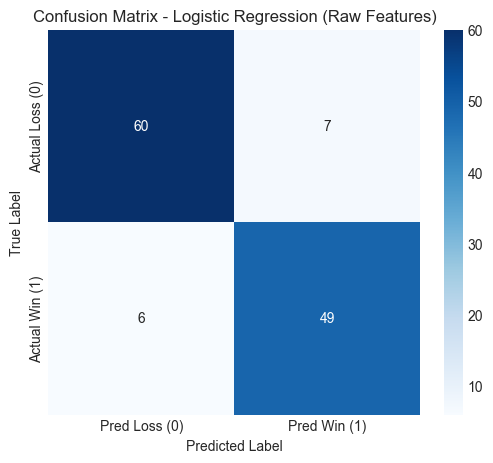

In [18]:
accuracy = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)

# -------------------------
# Print metrics (clean format)
# -------------------------
print("="*50)
print("MODEL PERFORMANCE (Logistic Regression)")
print("="*50)
print(f"Accuracy: {accuracy*100:.2f}%")
print(f"F1 Score : {f1*100:.2f}%")
print("="*50)

# -------------------------
# Confusion Matrix (Heatmap)
# -------------------------
plt.figure(figsize=(6,5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Pred Loss (0)", "Pred Win (1)"],
    yticklabels=["Actual Loss (0)", "Actual Win (1)"]
)

plt.title("Confusion Matrix - Logistic Regression (Raw Features)")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

Coefficients

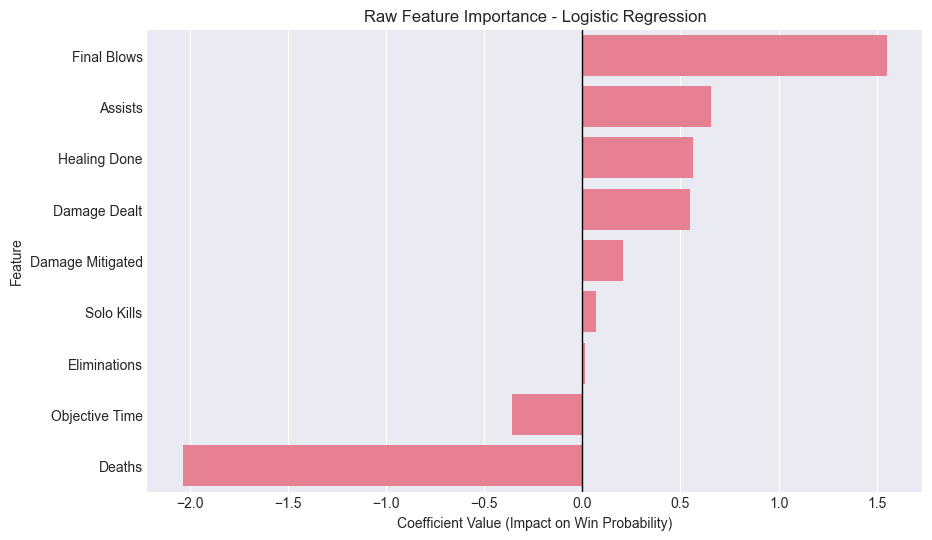

         Feature  Coefficient
     Final Blows     1.552853
         Assists     0.653994
    Healing Done     0.561375
    Damage Dealt     0.548382
Damage Mitigated     0.208883
      Solo Kills     0.070187
    Eliminations     0.012706
  Objective Time    -0.359002
          Deaths    -2.035509


In [19]:
coeffs = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_[0]
}).sort_values(by="Coefficient", ascending=False)

plt.figure(figsize=(10,6))

sns.barplot(
    x="Coefficient",
    y="Feature",
    data=coeffs
)

plt.title("Raw Feature Importance - Logistic Regression")
plt.xlabel("Coefficient Value (Impact on Win Probability)")
plt.ylabel("Feature")

plt.axvline(0, color="black", linewidth=1)
plt.show()
print(coeffs.to_string(index=False))

In [20]:
scores = cross_val_score(model, X, y, cv=5, scoring="f1")
print("CV F1:", scores.mean())

CV F1: 0.9200773017357428


##### <b>What This Tells Us:</b>

Model has strong performance, accuracy is around 89%, F1 score is around 88%, with a Cross-Validation F1 score of 92%. While the CV F1 score was higher, it wasn't extremely different. This could be explained by having a harder random test split. Overall I am not concerned due to it being less than a 4% difference. Our scores tell us our model is accurate and has good generalization, stable behavior and low variance between training/testing splits. There does not seem to be any over or under fitting.

Our model made 122 predictions (20% of our total), 109 were correct (60 losses, 49 wins), with 12 incorrect predictions (7 losses predicted as a win, 6 wins predicted as a loss).

The most important stat is deaths. Having more deaths significanlty decreases your chances to win, with a coefficient of -2.04. This aligns strongly with Overwatch gameplay where teams work together, and missing a single person (20% of the team) could throw off a plan.
Final Blows was the second most important with a +1.55 coefficient. This is believable, because if nobody is getting the final hit after a team does damage to an enemy, that means they survived, are able to heal, and come back to fight again. Securing eliminations also increases the enemy's deaths, which as we see above has a significant negative impact to their likelihood of winning. Interestingly enough, eliminations themselves only had a coefficient of 0.01, which may be because Final Blows already basically covers this stat. This is called multicollinearity. Since so many stats are based around getting kills (Final Blows, Eliminations, Assists, Damage Dealt), I was not surprised to see this happen.
Assists were the next most important (coefficient of +0.65), again an assist means a kill happened, thus increasing the enemy's deaths.
Healing Done had a coefficient of +0.56. This also aligns with staying alive, and one could assume being healed more means staying alive more.
Damage Dealt, another stat aimed at kills, but also assists. Having a coefficient of +0.55 seems logical.
Objective Time is surprising at -0.36. This may show that a losing team tends to run to the objective to try to keep the game going, but it fails. It may also mean that dominant teams win fights quickly, thus lowering total objective time. High objective time may correlate with struggling on the defensive, unable to secure eliminations, versus being able to quickly secure eliminations leading to a much lower objective time.

## <b>Random Forest</b>

In [21]:
from sklearn.ensemble import RandomForestClassifier

In [22]:
tree_count = 500 # Tested 200 - 10,000 (for fun, I know 500 would probably be the upper bound at this point). Not much of a difference except for compute time.
tree_depth = 10

In [23]:
rf_model = RandomForestClassifier(
    n_estimators=tree_count,
    max_depth=tree_depth,
    random_state=42
)

In [24]:
rf_model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",500
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y

In [25]:
rf_pred = rf_model.predict(X_test)

In [26]:
rf_accuracy = accuracy_score(y_test, rf_pred)
rf_f1 = f1_score(y_test, rf_pred)
rf_cm = confusion_matrix(y_test, rf_pred)

MODEL PERFORMANCE (Random Forest)
Accuracy: 91.80%
F1 Score : 90.74%


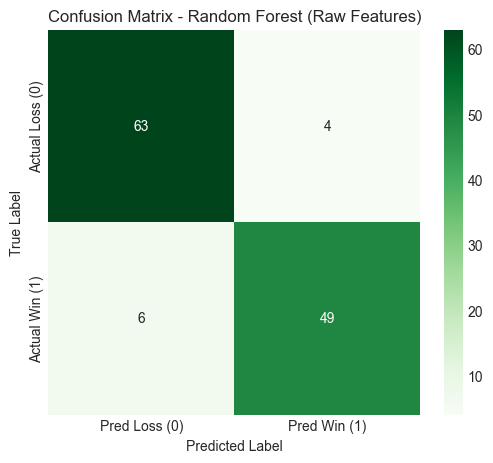

In [27]:
# -------------------------
# Print the stats cleanly
# -------------------------
print("="*50)
print("MODEL PERFORMANCE (Random Forest)")
print("="*50)
print(f"Accuracy: {rf_accuracy*100:.2f}%")
print(f"F1 Score : {rf_f1*100:.2f}%")
print("="*50)

# --------------------------------------------------
# Confusion Matrix (Heatmap again because it is cool)
# --------------------------------------------------

plt.figure(figsize=(6,5))

sns.heatmap(
    rf_cm,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=["Pred Loss (0)", "Pred Win (1)"],
    yticklabels=["Actual Loss (0)", "Actual Win (1)"]
)

plt.title("Confusion Matrix - Random Forest (Raw Features)")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.show()

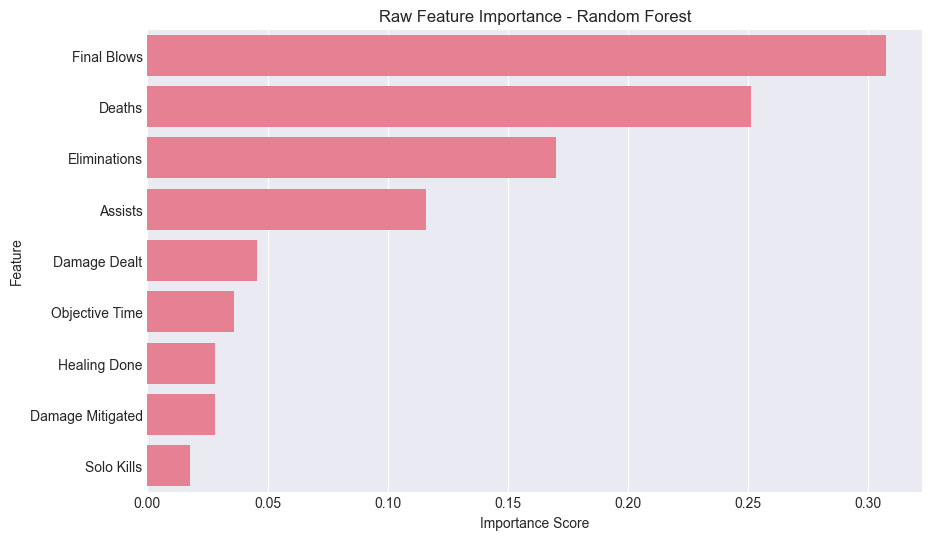

         Feature  Importance
     Final Blows    0.307193
          Deaths    0.251085
    Eliminations    0.169849
         Assists    0.115915
    Damage Dealt    0.045762
  Objective Time    0.036235
    Healing Done    0.028217
Damage Mitigated    0.027944
      Solo Kills    0.017798


In [28]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
}).sort_values(by="Importance", ascending=False)

plt.figure(figsize=(10,6))

sns.barplot(
    x="Importance",
    y="Feature",
    data=importance
)

plt.title("Raw Feature Importance - Random Forest")
plt.xlabel("Importance Score")
plt.ylabel("Feature")

plt.show()

print(importance.to_string(index=False))

In [29]:
rf_scores = cross_val_score(
    rf_model,
    X,
    y,
    cv=5,
    scoring="f1"
)

print("Random Forest CV F1:", rf_scores.mean())

Random Forest CV F1: 0.9195821411936922


##### <b>What This Tells Us:</b>

|Model|Accuracy|F1 Score|Cross-Validation F1|
|---|---|---|---|
|Logistic Regression|89.34%|88.29%|92.01%|
|Random Forest|91.80%|90.74%|92.12%|

The Random Forest model slightly outperformed Logistic Regression in both accuracy and F1 score, suggesting that nonlinear relationships exist between team statistics and match outcomes. However, the improvement was modest at best, indicating that much of the predictive capability is already captured by linear relationships in the data. Feature importance revealed that Final Blows and Deaths were the most influential predictors, emphasizing that match outcomes are primarily determined by fight efficiency and survivability rather than raw damage, objective time, or other stats.

NOTE: Deaths being an important feature does not mean high deaths is good. This model tells us importance, not direction.

## <b>Gradient Boosting</b>

In [30]:
from sklearn.ensemble import GradientBoostingClassifier

In [31]:
tree_amount = 500 # 500-600 are better than 400 and 700
learn_rate = 0.05 # .05 is better than .1 and .01

In [32]:
gb_model = GradientBoostingClassifier(
    n_estimators=tree_amount,
    learning_rate=learn_rate,
    max_depth=3,
    random_state=42
)

gb_model.fit(X_train, y_train)

,"loss loss: {'log_loss', 'exponential'}, default='log_loss'The loss function to be optimized. 'log_loss' refers to binomial andmultinomial deviance, the same as used in logistic regression.It is a good choice for classification with probabilistic outputs.For loss 'exponential', gradient boosting recovers the AdaBoost algorithm.",'log_loss'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.For an example of the effects of this parameter and its interaction with``subsample``, see:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_regularization.py`.",0.05
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",500
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'The function to measure the quality of a split. Supported criteria are'friedman_mse' for the mean squared error with improvement score byFriedman, 'squared_error' for mean squared error. The default value of'friedman_mse' is generally the best as it can provide a betterapproximation in some cases... versionadded:: 0.18",'friedman_mse'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``,

In [33]:
gb_pred = gb_model.predict(X_test)

In [34]:
gb_accuracy = accuracy_score(y_test, gb_pred)
gb_f1 = f1_score(y_test, gb_pred)
gb_cm = confusion_matrix(y_test, gb_pred)

MODEL PERFORMANCE (Gradient Boosting)
Accuracy: 94.26%
F1 Score : 93.46%


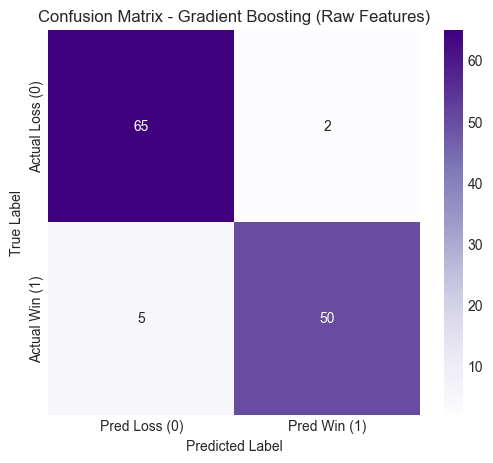

In [35]:
print("="*50)
print("MODEL PERFORMANCE (Gradient Boosting)")
print("="*50)
print(f"Accuracy: {gb_accuracy*100:.2f}%")
print(f"F1 Score : {gb_f1*100:.2f}%")
print("="*50)

plt.figure(figsize=(6,5))

sns.heatmap(
    gb_cm,
    annot=True,
    fmt="d",
    cmap="Purples",
    xticklabels=["Pred Loss (0)", "Pred Win (1)"],
    yticklabels=["Actual Loss (0)", "Actual Win (1)"]
)

plt.title("Confusion Matrix - Gradient Boosting (Raw Features)")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.show()

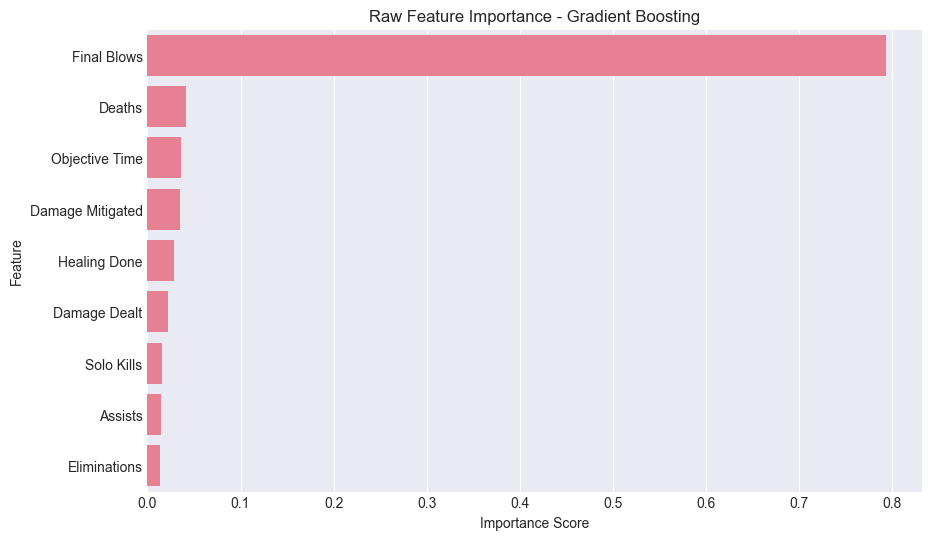

         Feature  Importance
     Final Blows    0.792593
          Deaths    0.041265
  Objective Time    0.036526
Damage Mitigated    0.034882
    Healing Done    0.028320
    Damage Dealt    0.022343
      Solo Kills    0.015726
         Assists    0.014685
    Eliminations    0.013660


In [36]:
gb_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": gb_model.feature_importances_
}).sort_values(by="Importance", ascending=False)

plt.figure(figsize=(10,6))

sns.barplot(
    x="Importance",
    y="Feature",
    data=gb_importance
)

plt.title("Raw Feature Importance - Gradient Boosting")
plt.xlabel("Importance Score")
plt.ylabel("Feature")

plt.show()

print(gb_importance.to_string(index=False))

In [37]:
gb_scores = cross_val_score(
    gb_model,
    X,
    y,
    cv=5,
    scoring="f1"
)

print("Gradient Boosting CV F1:", gb_scores.mean())

Gradient Boosting CV F1: 0.9223586751516617


##### <b>What This Tells Us:</b>

|Model|Accuracy|F1 Score|Cross-Validation F1|
|---|---|---|---|
|Logistic Regression|89.34%|88.29%|92.01%|
|Random Forest|91.80%|90.74%|92.12%|
|Gradient Boosting|94.26%|93.46%|92.24%|

This model was the best of all (as expected).
Feature importance is now surprising. Final Blows still dominates, at 0.79, but Deaths in second place is only 0.04. This is a big change from before, but it isn't saying that deaths are useless. More than likely the model is able to predict easily with Final Blows, giving less importance to Deaths and the other features.

# <b>Engineered Features</b>

## <b>Logistic Regression</b>

In [38]:
features_raw = [
    "Eliminations", "Damage Dealt", "Assists", "Objective Time",
    "Damage Mitigated", "Healing Done", "Deaths",
    "Solo Kills", "Final Blows"
]

In [39]:
team_stats_raw = df.groupby(
    ["match_id", "round_num", "team"]
)[features_raw].sum().reset_index()

team_results_raw = df.groupby(
    ["match_id", "round_num", "team"]
)["Result"].first().reset_index()

In [40]:
team_data_frame = team_stats.merge(
    team_results,
    on=["match_id", "round_num", "team"]
)

In [41]:
team_data_frame["Deaths_safe"] = team_data_frame["Deaths"].replace(0, 1) # Avoid divide by 0

In [42]:
team_data_frame["KD"] = team_data_frame["Eliminations"] / team_data_frame["Deaths_safe"]
team_data_frame["Damage_per_Death"] = (team_data_frame["Damage Dealt"] / team_data_frame["Deaths_safe"])
team_data_frame["Assists_per_Death"] = (team_data_frame["Assists"] / team_data_frame["Deaths_safe"])
team_data_frame["Mitigated_per_Death"] = (team_data_frame["Damage Mitigated"] / team_data_frame["Deaths_safe"])
team_data_frame["Healing_per_Death"] = (team_data_frame["Healing Done"] / team_data_frame["Deaths_safe"])

I am keeping objective time and final blows

In [43]:
features = [
    "KD",
    "Damage_per_Death",
    "Assists_per_Death",
    "Mitigated_per_Death",
    "Healing_per_Death",
    "Objective Time",
    "Final Blows"
]

In [44]:
team_data_frame["Result"] = team_data_frame["Result"].replace({5: 1})

grouped = team_data_frame.groupby(["match_id", "round_num"])

In [45]:
X_rows = []
y_rows = []

for (match, round_), group in grouped:

    if len(group) != 2:
        continue

    t1 = group.iloc[0]
    t2 = group.iloc[1]

    diff = t1[features] - t2[features]

    X_rows.append(diff.values)
    y_rows.append(int(t1["Result"]))

X = pd.DataFrame(X_rows, columns=features)
y = pd.Series(y_rows)

In [46]:
X = pd.DataFrame(X_rows, columns=features)
y = pd.Series(y_rows)

Train/Split

In [47]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [48]:
scaler = StandardScaler()

In [49]:
X_train = scaler.fit_transform(X_train)

In [50]:
X_test = scaler.transform(X_test)

In [51]:
model = LogisticRegression(max_iter=5000)

In [52]:
model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [53]:
y_pred = model.predict(X_test)

MODEL PERFORMANCE (Logistic Regression)
Accuracy: 91.80%
F1 Score : 90.91%


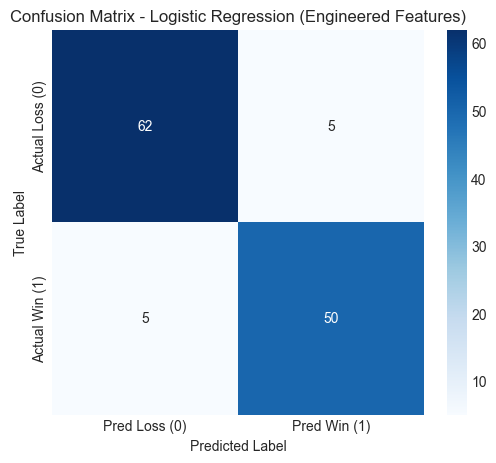

In [54]:
accuracy = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)

# -------------------------
# Print metrics (clean format)
# -------------------------
print("="*50)
print("MODEL PERFORMANCE (Logistic Regression)")
print("="*50)
print(f"Accuracy: {accuracy*100:.2f}%")
print(f"F1 Score : {f1*100:.2f}%")
print("="*50)

# -------------------------
# Confusion Matrix (Heatmap)
# -------------------------
plt.figure(figsize=(6,5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Pred Loss (0)", "Pred Win (1)"],
    yticklabels=["Actual Loss (0)", "Actual Win (1)"]
)

plt.title("Confusion Matrix - Logistic Regression (Engineered Features)")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

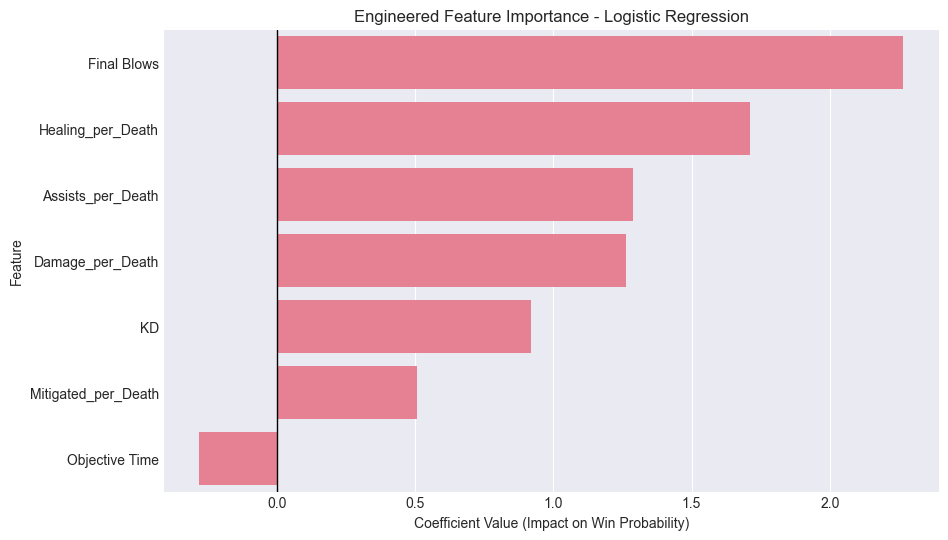

            Feature  Coefficient
        Final Blows     2.266404
  Healing_per_Death     1.713148
  Assists_per_Death     1.288323
   Damage_per_Death     1.262096
                 KD     0.917648
Mitigated_per_Death     0.508407
     Objective Time    -0.281992


In [55]:
coeffs = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_[0]
}).sort_values(by="Coefficient", ascending=False)

plt.figure(figsize=(10,6))

sns.barplot(
    x="Coefficient",
    y="Feature",
    data=coeffs
)

plt.title("Engineered Feature Importance - Logistic Regression")
plt.xlabel("Coefficient Value (Impact on Win Probability)")
plt.ylabel("Feature")

plt.axvline(0, color="black", linewidth=1)
plt.show()
print(coeffs.to_string(index=False))

In [56]:
scores = cross_val_score(model, X, y, cv=5, scoring="f1")
print("CV F1:", scores.mean())

CV F1: 0.9104467312973288


##### <b>Updated Table:</b>

|Model|Feature Set|Accuracy|F1 Score|Cross-Validation F1|
|---|---|---|---|---|
|Logistic Regression|Raw|89.34%|88.29%|92.01%|
|Logistic Regression|Engineered|91.80%|90.91%|91.04%|

Slightly better overall.

## <b>Random Forest</b>

In [57]:
tree_count = 500 # Tested 200 - 10,000 (for fun, I know 500 would probably be the upper bound at this point). Not much of a difference except for compute time.
tree_depth = 10

In [58]:
rf_model = RandomForestClassifier(
    n_estimators=tree_count,
    max_depth=tree_depth,
    random_state=42
)

In [59]:
rf_model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",500
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y

In [60]:
rf_pred = rf_model.predict(X_test)

In [61]:
rf_accuracy = accuracy_score(y_test, rf_pred)
rf_f1 = f1_score(y_test, rf_pred)
rf_cm = confusion_matrix(y_test, rf_pred)

MODEL PERFORMANCE (Random Forest)
Accuracy: 91.80%
F1 Score : 90.74%


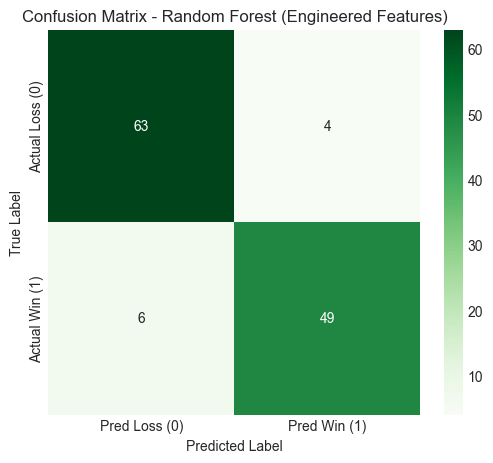

In [62]:
# -------------------------
# Print the stats cleanly
# -------------------------
print("="*50)
print("MODEL PERFORMANCE (Random Forest)")
print("="*50)
print(f"Accuracy: {rf_accuracy*100:.2f}%")
print(f"F1 Score : {rf_f1*100:.2f}%")
print("="*50)

# --------------------------------------------------
# Confusion Matrix (Heatmap again because it is cool)
# --------------------------------------------------

plt.figure(figsize=(6,5))

sns.heatmap(
    rf_cm,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=["Pred Loss (0)", "Pred Win (1)"],
    yticklabels=["Actual Loss (0)", "Actual Win (1)"]
)

plt.title("Confusion Matrix - Random Forest (Engineered Features)")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.show()

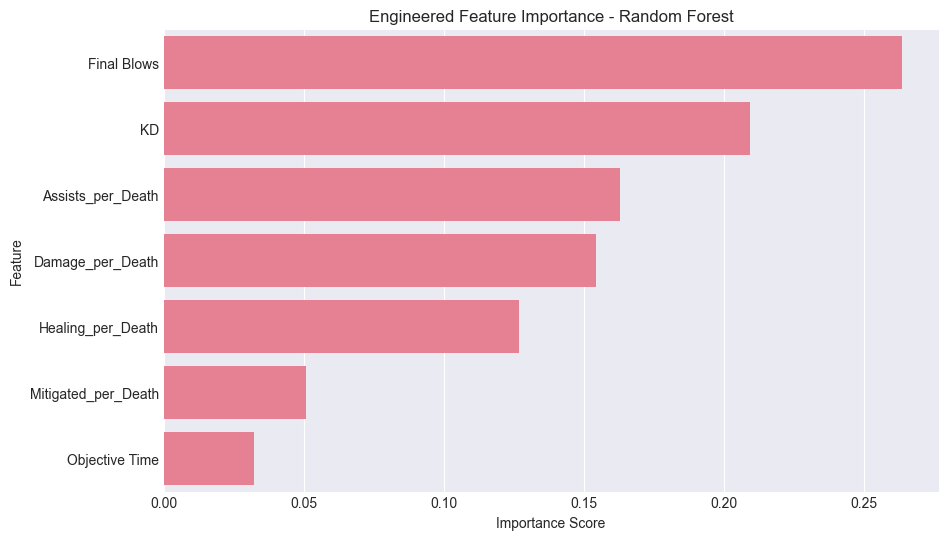

            Feature  Importance
        Final Blows    0.263578
                 KD    0.209299
  Assists_per_Death    0.162888
   Damage_per_Death    0.154519
  Healing_per_Death    0.126739
Mitigated_per_Death    0.050703
     Objective Time    0.032274


In [63]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
}).sort_values(by="Importance", ascending=False)

plt.figure(figsize=(10,6))

sns.barplot(
    x="Importance",
    y="Feature",
    data=importance
)

plt.title("Engineered Feature Importance - Random Forest")
plt.xlabel("Importance Score")
plt.ylabel("Feature")

plt.show()

print(importance.to_string(index=False))

In [64]:
rf_scores = cross_val_score(
    rf_model,
    X,
    y,
    cv=5,
    scoring="f1"
)

print("Random Forest CV F1:", rf_scores.mean())

Random Forest CV F1: 0.9170080561395743


##### <b>Updated Table:</b>

|Model|Feature Set|Accuracy|F1 Score|Cross-Validation F1|
|---|---|---|---|---|
|Random Forest|Raw|91.80%|90.74%|92.12%|
|Random Forest|Engineered|90.98%|89.91%|92.12%|

Very similar, but slightly worse.

## <b>Gradient Boosting</b>

In [65]:
tree_amount = 1000 # Bests From Tests
learn_rate = 0.1 # Bests From Tests

In [66]:
gb_model = GradientBoostingClassifier(
    n_estimators=tree_amount,
    learning_rate=learn_rate,
    max_depth=3,
    random_state=42
)

gb_model.fit(X_train, y_train)

,"loss loss: {'log_loss', 'exponential'}, default='log_loss'The loss function to be optimized. 'log_loss' refers to binomial andmultinomial deviance, the same as used in logistic regression.It is a good choice for classification with probabilistic outputs.For loss 'exponential', gradient boosting recovers the AdaBoost algorithm.",'log_loss'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.For an example of the effects of this parameter and its interaction with``subsample``, see:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_regularization.py`.",0.1
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",1000
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'The function to measure the quality of a split. Supported criteria are'friedman_mse' for the mean squared error with improvement score byFriedman, 'squared_error' for mean squared error. The default value of'friedman_mse' is generally the best as it can provide a betterapproximation in some cases... versionadded:: 0.18",'friedman_mse'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``,

In [67]:
gb_pred = gb_model.predict(X_test)

In [68]:
gb_accuracy = accuracy_score(y_test, gb_pred)
gb_f1 = f1_score(y_test, gb_pred)
gb_cm = confusion_matrix(y_test, gb_pred)

MODEL PERFORMANCE (Gradient Boosting)
Accuracy: 94.26%
F1 Score : 93.58%


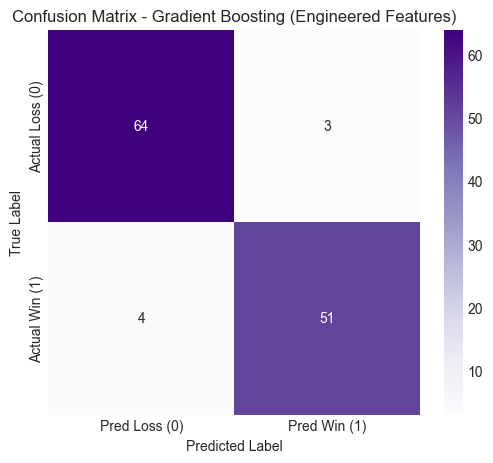

In [69]:
print("="*50)
print("MODEL PERFORMANCE (Gradient Boosting)")
print("="*50)
print(f"Accuracy: {gb_accuracy*100:.2f}%")
print(f"F1 Score : {gb_f1*100:.2f}%")
print("="*50)

plt.figure(figsize=(6,5))

sns.heatmap(
    gb_cm,
    annot=True,
    fmt="d",
    cmap="Purples",
    xticklabels=["Pred Loss (0)", "Pred Win (1)"],
    yticklabels=["Actual Loss (0)", "Actual Win (1)"]
)

plt.title("Confusion Matrix - Gradient Boosting (Engineered Features)")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.show()

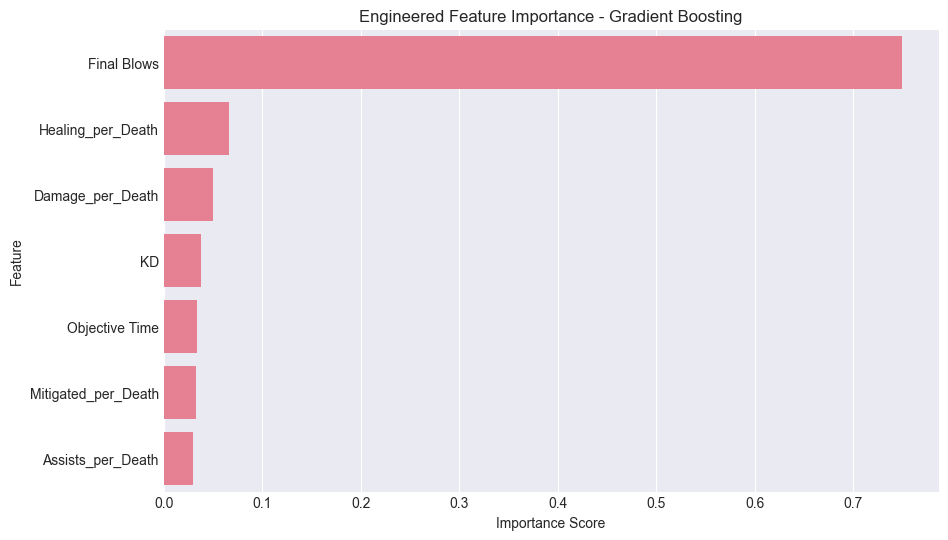

            Feature  Importance
        Final Blows    0.749125
  Healing_per_Death    0.066031
   Damage_per_Death    0.050203
                 KD    0.038035
     Objective Time    0.034105
Mitigated_per_Death    0.032830
  Assists_per_Death    0.029670


In [70]:
gb_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": gb_model.feature_importances_
}).sort_values(by="Importance", ascending=False)

plt.figure(figsize=(10,6))

sns.barplot(
    x="Importance",
    y="Feature",
    data=gb_importance
)

plt.title("Engineered Feature Importance - Gradient Boosting")
plt.xlabel("Importance Score")
plt.ylabel("Feature")

plt.show()

print(gb_importance.to_string(index=False))

In [71]:
gb_scores = cross_val_score(
    gb_model,
    X,
    y,
    cv=5,
    scoring="f1"
)

print("Gradient Boosting CV F1:", gb_scores.mean())

Gradient Boosting CV F1: 0.909134068095948


##### <b>Updated Table:</b>

|Model|Feature Set|Accuracy|F1 Score|Cross-Validation F1|
|---|---|---|---|---|
|Gradient Boosting|Raw|94.26%|93.46%|92.24%|
|Gradient Boosting|Engineered|94.26%|93.46%|90.91%|

Nearly identical.

# <b>Conclusion</b>

|Model|Feature Set|Accuracy|F1 Score|Cross-Validation F1|
|---|---|---|---|---|
|Logistic Regression|Raw|89.34%|88.29%|92.01%|
|Logistic Regression|Engineered|91.80%|90.91%|91.04%|
|Random Forest|Raw|91.80%|90.74%|92.12%|
|Random Forest|Engineered|90.98%|89.91%|92.12%|
|Gradient Boosting|Raw|94.26%|93.46%|92.24%|
|Gradient Boosting|Engineered|94.26%|93.46%|90.91%|

Feature engineering <b>did not</b> consistently improve results.

While Logistic Regression did see improvements when including engineered features, it was the only one. All models had decent accuracy, F1 and Cross-Validation F1 scores, however one stood above the rest. Gradient Boosting with raw and engineered features tied for the highest accuracy (94.26%) and highest F1 Score (93.46%). The Cross-Validation F1 score for the raw featured Gradient Boosting was the highest of all, but all were stable (lowest CV F1 being 90.91%). These results suggest that feature engineering can help simpler linear models capture relationships more effectively, but it does not necessarily improve performance for already powerful methods capable of learning complex nonlinear interactions. Gradient Boosting appears to already extract the most predictive structure from the original feature set, making additional ratio-based features less impactful. Overall, the results indicate that Gradient Boosting with raw features provides the most reliable balance between performance and stability. This suggests that the underlying game outcome is strongly driven by nonlinear interactions between the core gameplay statistics.

As for our original hypothesis, engineered features did not overall outperform raw statistics, the more complex models had better predictive power, and Final Blows is the most important stat in determining winning games.

At one point we thought to split stats between DPS, Tank, Support, but I think it is obvious that DPS will have the highest values.